Reference: Avellaneda & Lee (2008), *Statistical Arbitrage in the U.S. Equities Market*.

The starting point is a working stat-arb pipeline: PCA factor model, Ornstein-Uhlenbeck estimation
of the residuals, s-score trading rule, rolling backtest. This notebook extends it along three
independent axes, each isolated so that its effect can be measured on its own.

| Section | Topic | Question |
|---|---|---|
| 1 | Two corrections to the original pipeline | Does the code do what its formulas say? |
| 2 | Sector ("synthetic ETF") factor model | Do GICS sector factors beat PCA components? |
| 3 | Kalman-filtered O-U estimation | Does a time-varying $\kappa$ beat a static OLS fit? |
| 4 | Both extensions combined | Do the two changes interact? |
| 5 | Regime breakdown and walk-forward | Do the full-sample results survive out of sample? |

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.statistical_arbitrage import (
    estimate_factor_model,
    estimate_all_ou_parameters,
    estimate_ou_window_residuals,
    estimate_ou_parameters,
    compute_s_score,
    compute_strategy_statistics,
)
from utilities.extensions import (
    load_sector_map,
    build_sector_factors,
    estimate_all_ou_parameters_kalman,
    kalman_ou_path,
    run_statarb_backtest,
    beta_neutralize_weights,
    sweep_entry_thresholds,
    regime_table,
    vol_regime_split_stats,
    walk_forward_threshold_selection,
)

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)


def run_cached(name, compute_fn):
    """Return checkpoints/<name>.pkl if it exists, otherwise compute and cache it.
    Delete the checkpoints/ folder to force a from-scratch rerun of every backtest
    below (~6-7 minutes on this 50-stock, 10-year universe)."""
    path = CHECKPOINT_DIR / f"{name}.pkl"
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    result = compute_fn()
    with open(path, "wb") as f:
        pickle.dump(result, f)
    return result


def format_stats_table(stats_dict):
    """Render a {label: stats} mapping as a display DataFrame: ratios as plain
    numbers, returns / volatility / drawdown as percentages. Keyed on column name
    rather than magnitude, so a Sharpe ratio near 1 is never shown as a return."""
    df = pd.DataFrame(stats_dict).T
    display_df = df.copy()
    for col in display_df.columns:
        if "ratio" in col.lower():
            display_df[col] = display_df[col].apply(lambda v: f"{v:.2f}")
        else:
            display_df[col] = display_df[col].apply(lambda v: f"{v:.2%}")
    return display_df

In [2]:
# Prices, volumes and GICS sector tags
data_path = Path("data")

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
).ffill()
volume = pd.read_csv(data_path / "volume.csv", index_col="Date", parse_dates=True)
sector_map = load_sector_map(data_path / "ticker_details.csv")

performance = last_prices.pct_change().iloc[1:]
print(f"Universe: {performance.shape[1]} stocks, {performance.shape[0]} trading days "
      f"({performance.index[0].date()} to {performance.index[-1].date()})")
print(f"\nGICS sector breakdown ({sector_map.nunique()} sectors):")
print(sector_map.value_counts())

Universe: 50 stocks, 2598 trading days (2013-01-03 to 2023-02-17)

GICS sector breakdown (11 sectors):
GICS
Consumer Discretionary    11
Financials                11
Industrials                6
Consumer Staples           5
Materials                  4
Information Technology     4
Health Care                3
Utilities                  2
Energy                     2
Communication Services     1
Real Estate                1
Name: count, dtype: int64


In [3]:
# Kept identical to the baseline pipeline, so that every variant below differs
# in exactly one component
estimation_window = 252       # 1 year of data for factor-model estimation
ou_estimation_window = 60     # 60 business days for O-U estimation
n_factors = 15                # Number of PCA factors (baseline)

s_bo = s_so = 1.25            # Entry thresholds
s_bc = s_sc = 0.50            # Exit thresholds
min_mean_reversion_speed = 252 / 30
min_coverage = 0.95
transaction_costs = 5e-4


def pca_factor_builder(cur_perf):
    return estimate_factor_model(cur_perf, n_factors=n_factors)["factors"]


def sector_factor_builder(cur_perf):
    return build_sector_factors(cur_perf, sector_map)


equal_weight_benchmark_returns = performance.mean(axis=1)

---
# 1. Two corrections to the original pipeline

## 1.1 The modified s-score never receives alpha

The paper's modified s-score is

$$s_{mod,t} = \frac{X_t - m}{\sigma_{eq}} - \frac{\alpha}{\kappa\,\sigma_{eq}}$$

and `compute_s_score(..., modified=True, alphas=...)` implements it correctly, provided an `alphas`
Series is supplied. The original backtest loop calls `compute_s_score(cum_residuals_ou, ou_params, True)`
without it, so `alphas` falls back to its default of `None` and `alpha` is silently set to zero for
every asset. The loop therefore trades the plain score $s_t = (X_t - m)/\sigma_{eq}$ while asking for
the modified one. The alpha series it needs is already produced by `estimate_ou_window_residuals`
(the intercept of that same 60-day regression); it is simply never threaded through.

`run_statarb_backtest` in `utilities/extensions.py` closes the gap (`use_alpha_adjustment=True` by
default). Both behaviours are backtested below from a single pass over the same factor and O-U
computation, so the comparison isolates one line of code.

## 1.2 The beta-neutral weights are computed and then discarded

The original notebook builds `weights_beta_neutral` — an equal-weight book hedged against an
equal-weighted market proxy using each day's realized covariance matrix — immediately after
`weights`, and then runs `backtest(weights, performance)`. The hedge is never used.
`beta_neutralize_weights` extracts the same logic into a reusable function and applies it, as a
market-neutral strategy requires.

In [4]:
def _compute_baseline():
    res = run_statarb_backtest(
        performance, pca_factor_builder, estimate_all_ou_parameters,
        use_alpha_adjustment=True, track_both_alpha_variants=True,
    )
    cum = backtest(res["weights"], performance)
    cum_costs = backtest(res["weights"], performance, transaction_costs=transaction_costs)
    cum_no_alpha = backtest(res["weights_no_alpha"], performance)
    weights_bn = beta_neutralize_weights(res["weights"], performance, res["covariance_matrices"])
    cum_bn = backtest(weights_bn, performance)
    return dict(
        weights=res["weights"], cum=cum, cum_costs=cum_costs,
        stats=compute_strategy_statistics(cum.dropna()),
        s_scores=res["s_scores"], ou_params=res["ou_params"],
        cum_no_alpha=cum_no_alpha, stats_no_alpha=compute_strategy_statistics(cum_no_alpha.dropna()),
        cum_bn=cum_bn, stats_bn=compute_strategy_statistics(cum_bn.dropna()),
    )


baseline = run_cached("baseline", _compute_baseline)

comparison = format_stats_table({
    "As shipped (alpha=0 bug)": baseline["stats_no_alpha"],
    "Alpha-fixed (this notebook's default from here on)": baseline["stats"],
    "Alpha-fixed + beta-neutral hedge applied": baseline["stats_bn"],
})
print("Baseline PCA + OLS O-U — effect of the two fixes:")
print(comparison.to_string())

Baseline PCA + OLS O-U — effect of the two fixes:
                                                   total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
As shipped (alpha=0 bug)                                 41.57%             3.81%                 5.49%         0.69       -9.54%
Alpha-fixed (this notebook's default from here on)       40.79%             3.74%                 5.48%         0.68       -9.54%
Alpha-fixed + beta-neutral hedge applied                 42.14%             3.85%                 4.54%         0.85       -7.33%


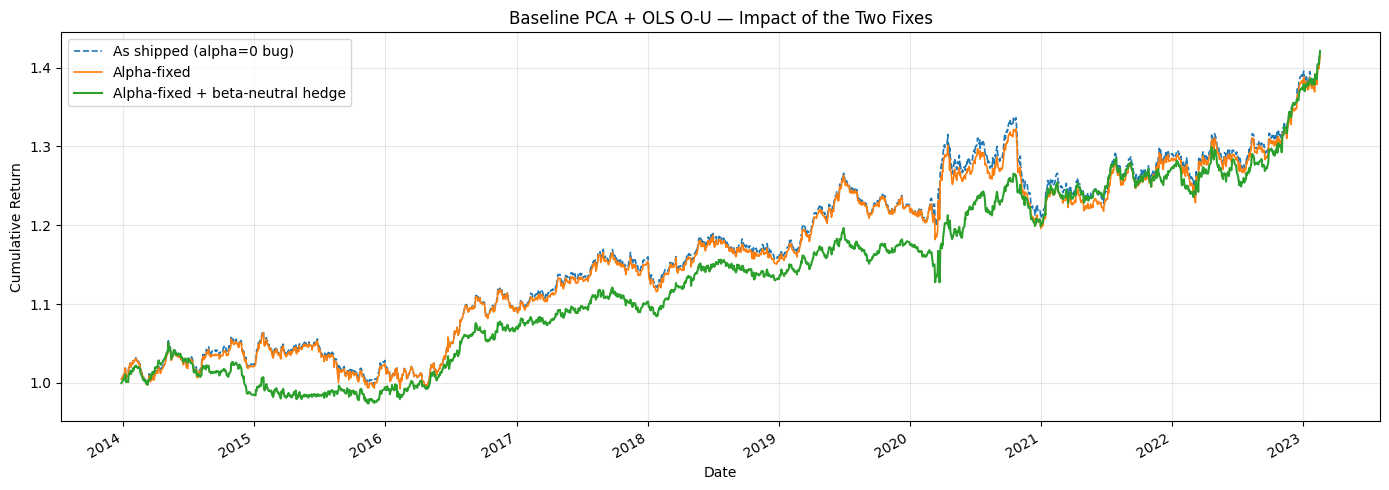

In [5]:
plt.figure(figsize=(14, 5))
baseline["cum_no_alpha"].plot(label="As shipped (alpha=0 bug)", linewidth=1.2, linestyle="--")
baseline["cum"].plot(label="Alpha-fixed", linewidth=1.2)
baseline["cum_bn"].plot(label="Alpha-fixed + beta-neutral hedge", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Baseline PCA + OLS O-U — Impact of the Two Fixes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The alpha correction is close to neutral on this universe (Sharpe 0.69 to 0.68): the residual drift
term is small relative to $\sigma_{eq}$, so it rarely flips a trading decision. It stays in because
it is the formula the paper actually specifies, but its measured effect here is within noise.

Applying the beta hedge is a clear improvement. Sharpe rises from 0.68 to 0.85 and maximum drawdown
shrinks from -9.5% to -7.3%: both move in the right direction, which is what a hedge that strips out
residual market exposure should do, as opposed to one that merely scales risk down. The alpha-fixed,
beta-neutral configuration is the reference baseline for the rest of the notebook.

In [6]:
# Reference for Sections 2-5: alpha-fixed, beta-neutral PCA/OLS
baseline_reference_cum = baseline["cum_bn"]
baseline_reference_stats = baseline["stats_bn"]

---
# 2. Extension 1 — sector ("synthetic ETF") factor model

Avellaneda & Lee's original US-equities implementation used a small set of tradable sector ETF
returns as the systematic factors; PCA came later as the alternative that avoids picking a sector
taxonomy and an investable proxy for each factor. This dataset ships with GICS tags
(`ticker_details.csv`), so both routes can be tested on the same universe.

`build_sector_factors` constructs one equal-weighted return series per GICS sector present in the
current estimation window, i.e. what an equal-weighted sector ETF would have returned, and feeds it
to `estimate_ou_window_residuals` in place of `factor_model["factors"]`. O-U estimation, s-score,
position update, portfolio construction and backtest are untouched.

In [7]:
# First fully populated estimation window, used as the calibration sample here
# and again in Section 3
for _date in performance.index:
    _cand, _diag = prepare_rolling_estimation_window(performance, _date, estimation_window, min_coverage, True)
    if _diag["row_count"] == estimation_window and _cand.shape[1] > 0:
        calibration_date, calibration_window = _date, _cand
        break

sector_factors_sample = build_sector_factors(calibration_window, sector_map)
print(f"Calibration window: {calibration_window.index[0].date()} to {calibration_window.index[-1].date()}")
print(f"Sector factors this window: {sector_factors_sample.shape[1]} "
      f"(of {sector_map.nunique()} GICS sectors — some have too few members present)")
print(sector_factors_sample.columns.tolist())

Calibration window: 2013-01-03 to 2013-12-24
Sector factors this window: 10 (of 11 GICS sectors — some have too few members present)
['Consumer Staples', 'Consumer Discretionary', 'Industrials', 'Materials', 'Financials', 'Information Technology', 'Health Care', 'Communication Services', 'Utilities', 'Energy']


## 2.1 Explanatory power: 10 sector factors vs. 15 PCA factors

Before running the backtest, the more basic question is how much of each stock's return variance
each factor set explains in sample, on the same 252-day window. This R² is the channel through which
a weaker factor model would be expected to hurt the downstream signal: factors that leave systematic
risk inside the residual produce a series that is not purely idiosyncratic, which contaminates the
O-U fit.

PCA    (15 factors): mean in-sample R^2 = 76.1%  (eigenvalue-based explained variance: 76.1%)
Sector (10 factors): mean in-sample R^2 = 62.5%


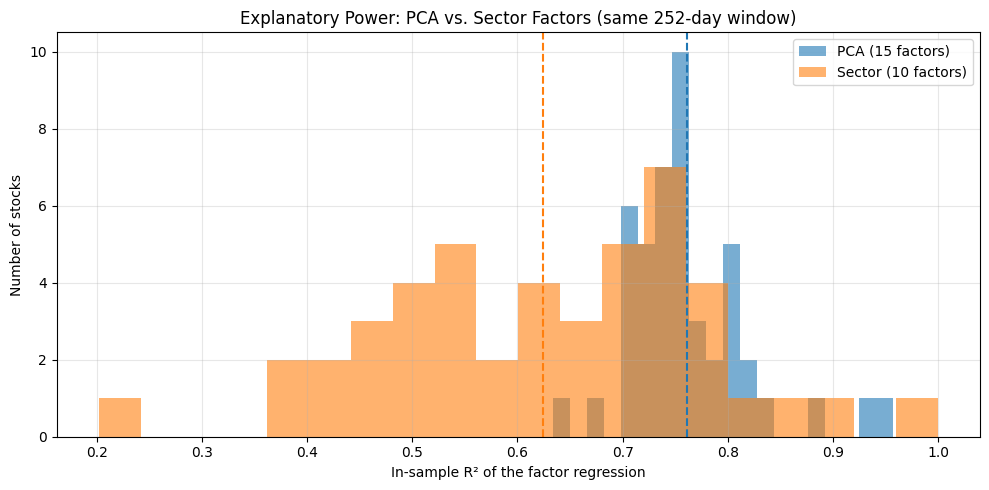

In [8]:
factor_model_sample = estimate_factor_model(calibration_window, n_factors=n_factors)
total_var = calibration_window.var()

r2_pca = (1 - factor_model_sample["residuals"].var() / total_var).clip(lower=0)
sector_residuals_sample = estimate_ou_window_residuals(
    calibration_window, sector_factors_sample, ou_window=None
)["residuals"]
r2_sector = (1 - sector_residuals_sample.var() / total_var).clip(lower=0)

print(f"PCA    ({n_factors} factors): mean in-sample R^2 = {r2_pca.mean():.1%}  "
      f"(eigenvalue-based explained variance: {factor_model_sample['explained_variance'].sum():.1%})")
print(f"Sector ({sector_factors_sample.shape[1]} factors): mean in-sample R^2 = {r2_sector.mean():.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(r2_pca, bins=20, alpha=0.6, label=f"PCA ({n_factors} factors)", color="tab:blue")
ax.hist(r2_sector, bins=20, alpha=0.6, label=f"Sector ({sector_factors_sample.shape[1]} factors)", color="tab:orange")
ax.axvline(r2_pca.mean(), color="tab:blue", linestyle="--")
ax.axvline(r2_sector.mean(), color="tab:orange", linestyle="--")
ax.set_xlabel("In-sample R² of the factor regression")
ax.set_ylabel("Number of stocks")
ax.set_title("Explanatory Power: PCA vs. Sector Factors (same 252-day window)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

On this window, 15 PCA factors explain 76.1% of variance on average against 62.5% for the 10 sector
factors. The gap is expected. PCA is fit to maximize explained variance on this universe, while GICS
is a fixed off-the-shelf taxonomy, and an unbalanced one here: Financials and Consumer Discretionary
have 11 members each, Communication Services and Real Estate exactly one. A single-stock "sector"
averages away no idiosyncratic noise and makes a poor factor.

This sets a prior for the backtest. If the sector residuals retain more systematic risk, the O-U
process is being fit to a noisier series and the trading signal should weaken rather than improve.

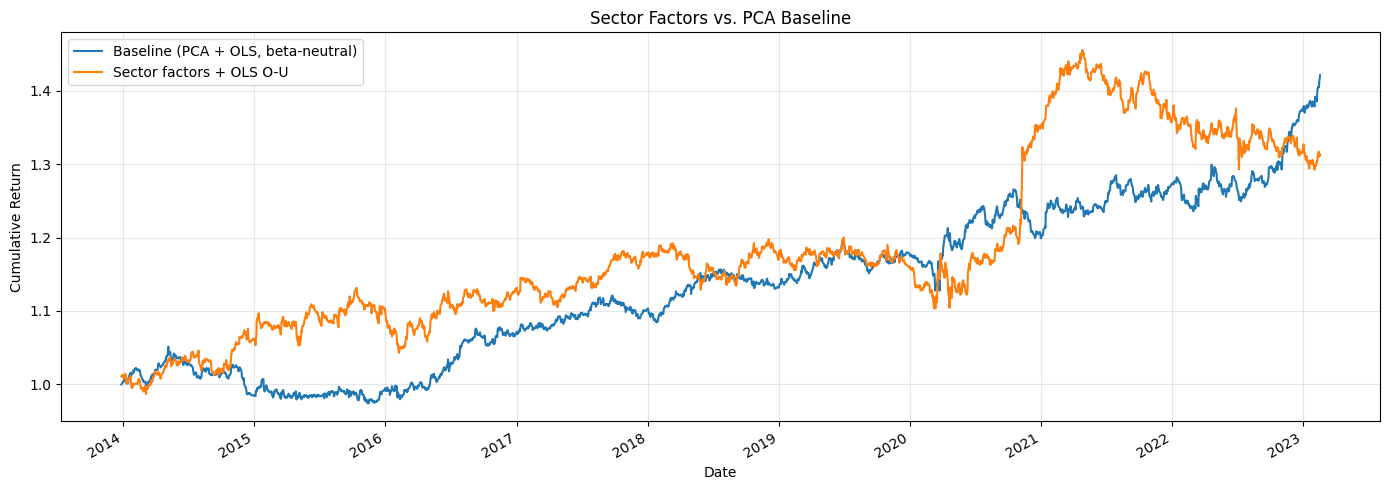

                             total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
Baseline (PCA, beta-neutral)       42.14%             3.85%                 4.54%         0.85       -7.33%
Sector factors                     29.91%             2.85%                 6.37%         0.45      -11.19%


In [9]:
def _compute_sector():
    res = run_statarb_backtest(performance, sector_factor_builder, estimate_all_ou_parameters)
    cum = backtest(res["weights"], performance)
    cum_costs = backtest(res["weights"], performance, transaction_costs=transaction_costs)
    return dict(
        weights=res["weights"], cum=cum, cum_costs=cum_costs,
        stats=compute_strategy_statistics(cum.dropna()),
        s_scores=res["s_scores"], ou_params=res["ou_params"],
    )


sector = run_cached("sector", _compute_sector)

plt.figure(figsize=(14, 5))
baseline_reference_cum.plot(label="Baseline (PCA + OLS, beta-neutral)", linewidth=1.5)
sector["cum"].plot(label="Sector factors + OLS O-U", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Sector Factors vs. PCA Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(format_stats_table({
    "Baseline (PCA, beta-neutral)": baseline_reference_stats,
    "Sector factors": sector["stats"],
}).to_string())

The backtest matches the prior: the sector variant delivers Sharpe 0.45 against 0.85 for the
baseline, with a drawdown of -11.2% against -7.3%. The negative result is worth reporting. It
quantifies why the PCA variant tends to be preferred on universes without a rich, balanced set of
tradable sector proxies, and it follows directly from the R² gap measured above rather than from
chance.

---
# 3. Extension 2 — Kalman-filtered O-U estimation

The original pipeline estimates $\kappa$, $m$ and $\sigma_{eq}$ for each asset by fitting the AR(1)
relation $X_t = a + b X_{t-1} + \varepsilon_t$ once by OLS over the whole 60-day window: a single
static estimate, discarded and rebuilt from scratch at the next rebalance date.

`estimate_ou_parameters_kalman` instead treats $\theta = (a, b)$ as a latent state following a random
walk, $\theta_t = \theta_{t-1} + w_t$, and filters it recursively through the window with a standard
linear Kalman filter: the recursive-least-squares-with-time-varying-coefficients formulation used
for adaptive hedge ratios in pairs trading.

Two implementation choices matter:

- **Informative prior.** $\theta_0$ and $P_0$ are set to the OLS estimate and covariance from a
  20-point warm-up fit. Under a diffuse prior, $b$ wanders outside $(0,1)$ within a handful of steps
  and the implied $\kappa$ stops meaning anything. This was the first thing to break while building
  the filter.
- **Process noise anchored to that prior.** $Q = \delta \cdot P_0$, which gives $\delta$ a clean
  reading: the fraction of the initial parameter uncertainty allowed to re-accumulate as drift at
  each step.

Only the final filtered state is used for trading, and it uses information up to the last day of the
window only, so the estimator stays exactly as causal as the original OLS fit.

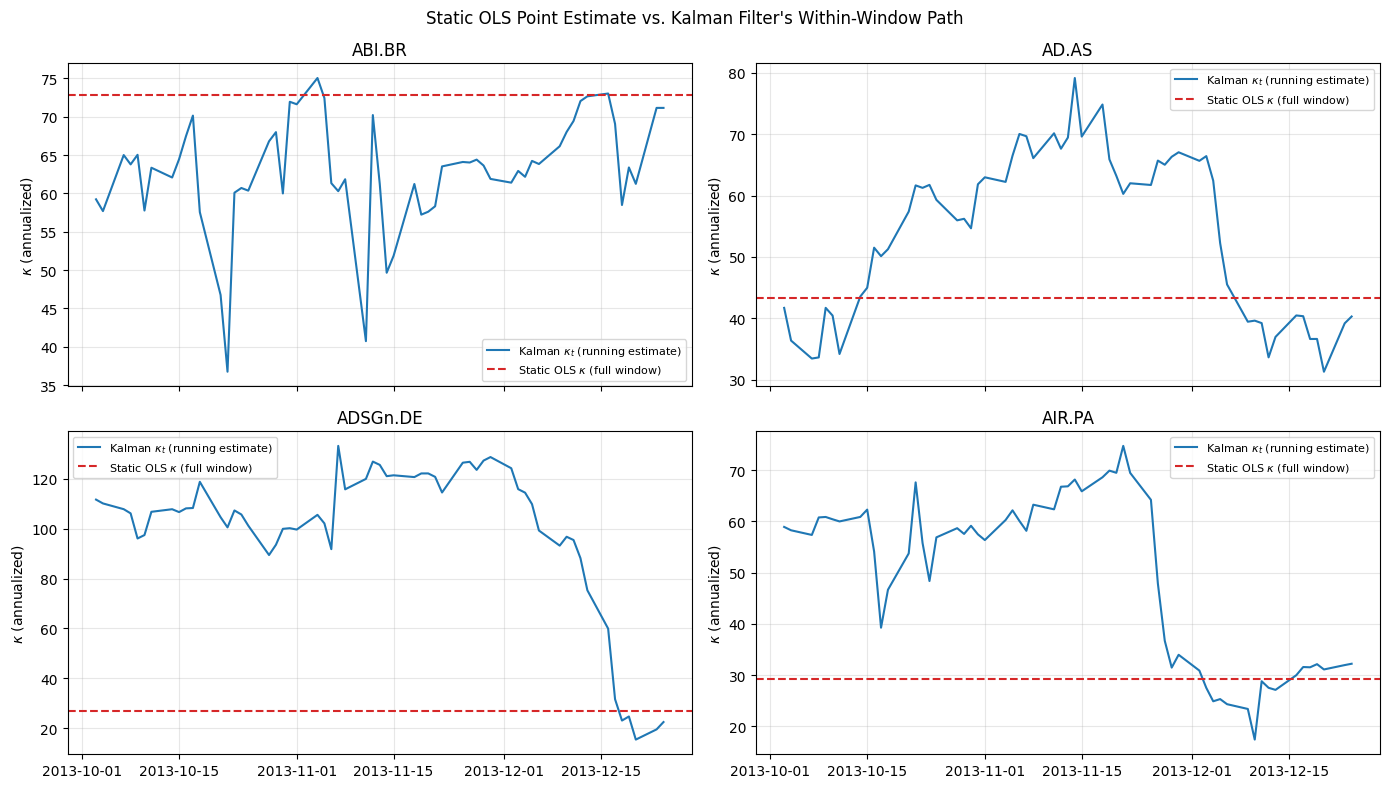

In [10]:
# Same calibration window and PCA factor model as Section 2.1
cum_res_sample = estimate_ou_window_residuals(
    calibration_window, factor_model_sample["factors"], ou_estimation_window
)["residuals"].cumsum()
sample_assets = list(cum_res_sample.columns)[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, asset in zip(axes.flat, sample_assets):
    r = cum_res_sample[asset].iloc[-ou_estimation_window:]
    path = kalman_ou_path(r, delta=1e-2, burn=20)
    static = estimate_ou_parameters(r, dt=1 / 252)
    ax.plot(path["index"], path["kappa_path"], label="Kalman $\\kappa_t$ (running estimate)", color="tab:blue")
    ax.axhline(static["kappa"], color="tab:red", linestyle="--", label="Static OLS $\\kappa$ (full window)")
    ax.set_title(asset)
    ax.set_ylabel("$\\kappa$ (annualized)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle("Static OLS Point Estimate vs. Kalman Filter's Within-Window Path")
plt.tight_layout()
plt.show()

The filtered path converges towards the static OLS value by the end of the window, as it should,
since both see the same 60 observations. Within the window it moves considerably: for `ADSGn.DE` the
filtered $\kappa_t$ ranges from roughly 15 to above 130, which the static fit compresses into a
single value near 27. The static estimate is not wrong, but it hides this instability.
Mean-reversion speed is not constant even inside the estimation window; whether that matters for the
trading signal is what the backtest below measures directly.

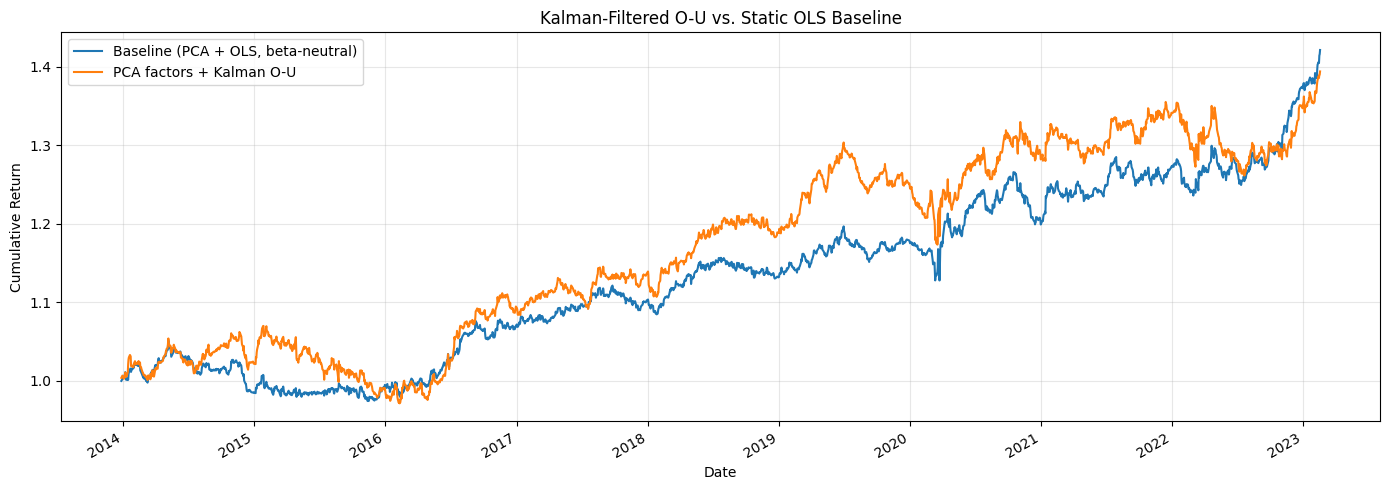

                             total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
Baseline (PCA, beta-neutral)       42.14%             3.85%                 4.54%         0.85       -7.33%
Kalman O-U                         38.87%             3.59%                 5.72%         0.63       -9.98%


In [11]:
def _compute_kalman():
    res = run_statarb_backtest(performance, pca_factor_builder, estimate_all_ou_parameters_kalman)
    cum = backtest(res["weights"], performance)
    cum_costs = backtest(res["weights"], performance, transaction_costs=transaction_costs)
    return dict(
        weights=res["weights"], cum=cum, cum_costs=cum_costs,
        stats=compute_strategy_statistics(cum.dropna()),
        s_scores=res["s_scores"], ou_params=res["ou_params"],
    )


kalman = run_cached("kalman", _compute_kalman)

plt.figure(figsize=(14, 5))
baseline_reference_cum.plot(label="Baseline (PCA + OLS, beta-neutral)", linewidth=1.5)
kalman["cum"].plot(label="PCA factors + Kalman O-U", linewidth=1.5)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Kalman-Filtered O-U vs. Static OLS Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(format_stats_table({
    "Baseline (PCA, beta-neutral)": baseline_reference_stats,
    "Kalman O-U": kalman["stats"],
}).to_string())

The Kalman variant lands below the baseline: Sharpe 0.63 against 0.85, with higher volatility
(5.7% vs. 4.5%) and a deeper drawdown. Smoothing the within-window instability does not translate
into a better entry/exit rule. The same smoothing also slows the response to a genuine change in
mean-reversion speed at the start of a new regime, which is when the signal matters most for this
kind of strategy. Useful to know before spending more effort tuning $\delta$ or the burn-in length.

---
# 4. Both extensions combined

Sector factors underperformed on their own and the Kalman estimator did not improve on OLS. The
combination is still worth running: two individually neutral changes can interact, and the sign of
that interaction is not obvious in advance.

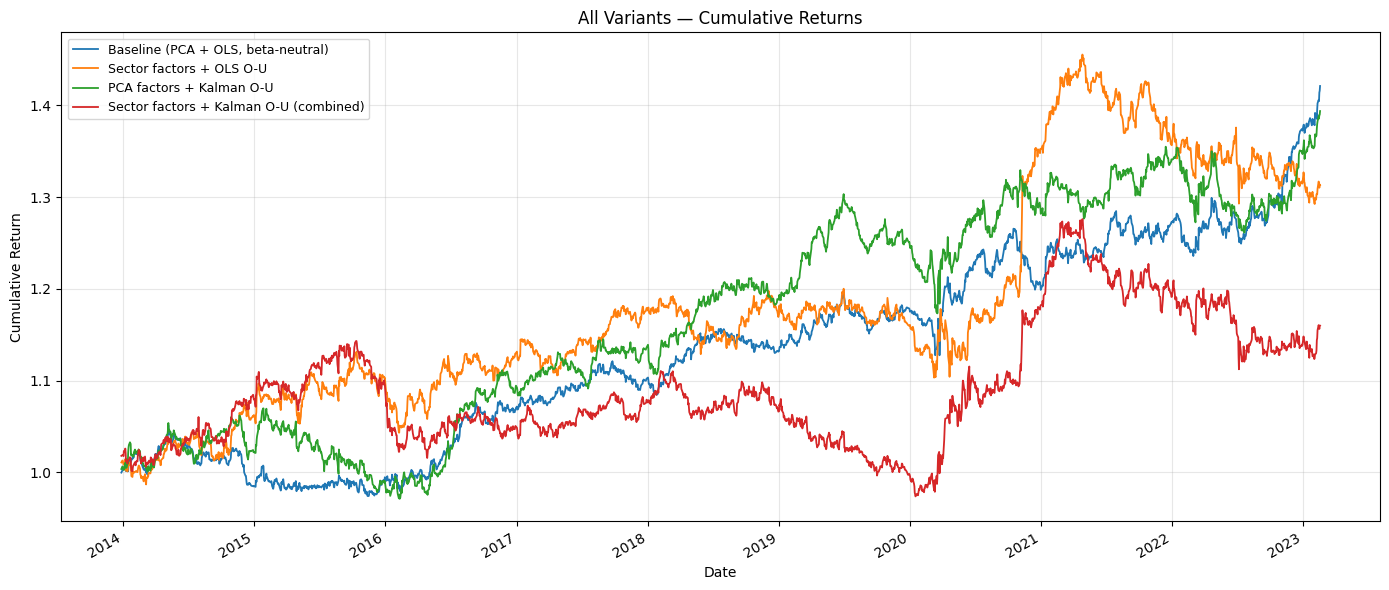

Full-sample comparison — all variants:
                             total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
Baseline (PCA, beta-neutral)       42.14%             3.85%                 4.54%         0.85       -7.33%
Sector factors                     29.91%             2.85%                 6.37%         0.45      -11.19%
Kalman O-U                         38.87%             3.59%                 5.72%         0.63       -9.98%
Combined (Sector + Kalman)         13.94%             1.41%                 6.46%         0.22      -14.81%


In [12]:
def _compute_combined():
    res = run_statarb_backtest(performance, sector_factor_builder, estimate_all_ou_parameters_kalman)
    cum = backtest(res["weights"], performance)
    cum_costs = backtest(res["weights"], performance, transaction_costs=transaction_costs)
    return dict(
        weights=res["weights"], cum=cum, cum_costs=cum_costs,
        stats=compute_strategy_statistics(cum.dropna()),
        s_scores=res["s_scores"], ou_params=res["ou_params"],
    )


combined = run_cached("combined", _compute_combined)

variants = {
    "Baseline\n(PCA + OLS, beta-neutral)": baseline_reference_cum,
    "Sector factors\n+ OLS O-U": sector["cum"],
    "PCA factors\n+ Kalman O-U": kalman["cum"],
    "Sector factors\n+ Kalman O-U\n(combined)": combined["cum"],
}

plt.figure(figsize=(14, 6))
for label, cum in variants.items():
    cum.plot(label=label.replace("\n", " "), linewidth=1.3)
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("All Variants — Cumulative Returns")
plt.legend(loc="upper left", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary_display = format_stats_table({
    "Baseline (PCA, beta-neutral)": baseline_reference_stats,
    "Sector factors": sector["stats"],
    "Kalman O-U": kalman["stats"],
    "Combined (Sector + Kalman)": combined["stats"],
})
print("Full-sample comparison — all variants:")
print(summary_display.to_string())

The combination is the weakest of the four variants (Sharpe 0.22, drawdown -14.8%), worse than
stacking the two individual shortfalls would suggest. Changes that are individually neutral or
mildly negative do not necessarily stay that way when applied together, which is the argument for
the one-variable-at-a-time structure used throughout this notebook. The alpha-fixed, beta-neutral
PCA/OLS baseline remains the best configuration tested and is the focus of the validation section.

---
# 5. Validation — regime breakdown and walk-forward selection

Everything so far is a full-sample comparison, which leaves two questions open. First, an average
can hide very different behaviour across market regimes. Second, choosing a hyperparameter such as
the entry threshold $s_{bo}$ by its full-sample Sharpe ratio is look-ahead: no desk gets to see the
whole backtest before committing to its parameters. Both are checked below.

## 5.1 Calendar regime breakdown

Sharpe ratio by calendar regime:
                Baseline (PCA)  Sector  Kalman  Combined
2014-2015                 0.14    0.76   -0.11      0.61
2016-2017                 1.34    0.82    1.57      0.07
2018-2019                 0.68   -0.14    1.07     -0.75
2020 (COVID)             -0.21    1.57    0.35      1.84
2021-2022                 1.22   -0.21    0.38     -0.26
2023 (partial)            2.59   -1.40    4.10      1.19


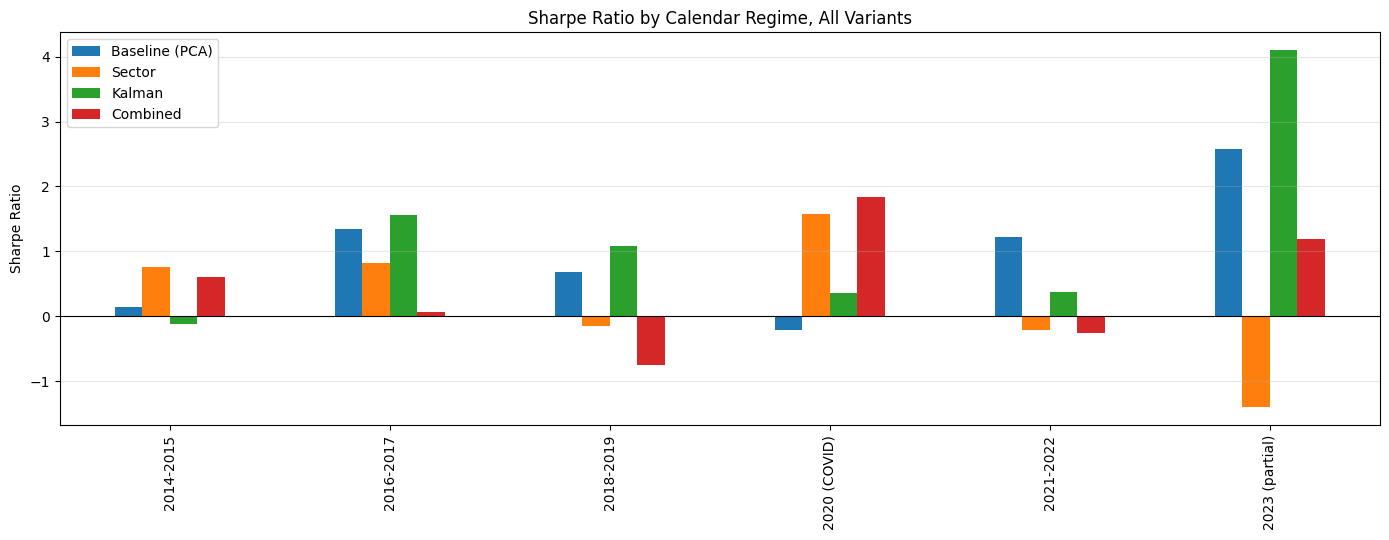

In [13]:
def _compute_analysis():
    regimes = {
        "2014-2015": ("2014-01-01", "2015-12-31"),
        "2016-2017": ("2016-01-01", "2017-12-31"),
        "2018-2019": ("2018-01-01", "2019-12-31"),
        "2020 (COVID)": ("2020-01-01", "2020-12-31"),
        "2021-2022": ("2021-01-01", "2022-12-31"),
        "2023 (partial)": ("2023-01-01", "2023-12-31"),
    }
    variant_results = {"baseline": baseline, "sector": sector, "kalman": kalman, "combined": combined}
    regime_tables = {name: regime_table(d["cum"], regimes, compute_strategy_statistics)
                      for name, d in variant_results.items()}
    vol_tables = {}
    for name, d in variant_results.items():
        strat_returns = d["cum"].pct_change().dropna()
        vol_tables[name] = vol_regime_split_stats(strat_returns, equal_weight_benchmark_returns)

    # Covariance matrices only: no factor model needed, so this is cheap. Used to
    # beta-neutralize every threshold variant consistently with Section 1.2
    covariance_matrices = {}
    for rebalance_date in performance.index:
        cur_perf, diag = prepare_rolling_estimation_window(
            performance, rebalance_date, estimation_window, min_coverage, True
        )
        if diag["row_count"] < estimation_window or cur_perf.shape[1] == 0:
            continue
        covariance_matrices[rebalance_date.to_pydatetime().date()] = cur_perf.cov()

    s_bo_grid = [0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
    threshold_weights = sweep_entry_thresholds(baseline["s_scores"], baseline["ou_params"], s_bo_grid)
    threshold_weights_bn = {
        thr: beta_neutralize_weights(w, performance, covariance_matrices)
        for thr, w in threshold_weights.items()
    }
    threshold_results_bn = {thr: backtest(w, performance) for thr, w in threshold_weights_bn.items()}
    threshold_results_plain = {thr: backtest(w, performance) for thr, w in threshold_weights.items()}

    fold_edges = ["2014-01-01", "2016-01-01", "2018-01-01", "2019-01-01",
                  "2020-01-01", "2021-01-01", "2022-01-01", "2023-01-01", "2023-12-31"]
    oos_cum, chosen = walk_forward_threshold_selection(threshold_results_bn, fold_edges)
    oos_cum_plain, chosen_plain = walk_forward_threshold_selection(threshold_results_plain, fold_edges)

    best_thr_full = max(
        threshold_results_bn,
        key=lambda k: compute_strategy_statistics(threshold_results_bn[k].dropna())["sharpe_ratio"],
    )

    return dict(
        regime_tables=regime_tables,
        vol_tables=vol_tables,
        threshold_results=threshold_results_bn,
        oos_cum=oos_cum,
        oos_stats=compute_strategy_statistics(oos_cum.dropna()),
        chosen_thresholds=chosen,
        best_thr_full=best_thr_full,
        best_stats_full=compute_strategy_statistics(threshold_results_bn[best_thr_full].dropna()),
        oos_cum_plain=oos_cum_plain,
        oos_stats_plain=compute_strategy_statistics(oos_cum_plain.dropna()),
        chosen_plain=chosen_plain,
    )


analysis = run_cached("analysis", _compute_analysis)

sharpe_by_regime = pd.DataFrame({
    name: tbl["sharpe_ratio"] for name, tbl in analysis["regime_tables"].items()
})
sharpe_by_regime.columns = ["Baseline (PCA)", "Sector", "Kalman", "Combined"]
print("Sharpe ratio by calendar regime:")
print(sharpe_by_regime.round(2).to_string())

sharpe_by_regime.plot(kind="bar", figsize=(14, 5.5))
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio by Calendar Regime, All Variants")
plt.legend(title=None)
plt.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

The full-sample ranking (baseline > Kalman > sector > combined) does not survive a regime split.
In 2020 it inverts: the sector variant posts its best year (Sharpe 1.57) while the PCA baseline
posts its worst (-0.21), and the combined variant is the best of all (1.84).

A plausible mechanism is that 2020 was a sector-driven dislocation, with travel and energy
collapsing while technology rallied. That is precisely the systematic move a small set of sector
factors is built to remove, leaving genuinely idiosyncratic residuals to mean-revert. PCA factors
fit on a trailing 252-day window still dominated by the pre-crash correlation structure adapt more
slowly to a break of that kind. The ordering reverses again in 2021-2022, where sector and combined
are the two weakest and PCA and Kalman hold up.

No variant dominates across regimes, so the full-sample average is a poor summary of which model is
better.

## 5.2 Volatility-regime split

Sharpe ratio, split by trailing benchmark volatility (median split):
                        Baseline (PCA)  Sector  Kalman  Combined
Low volatility regime             0.54    0.14    0.54     -0.18
High volatility regime            0.83    0.71    0.73      0.54


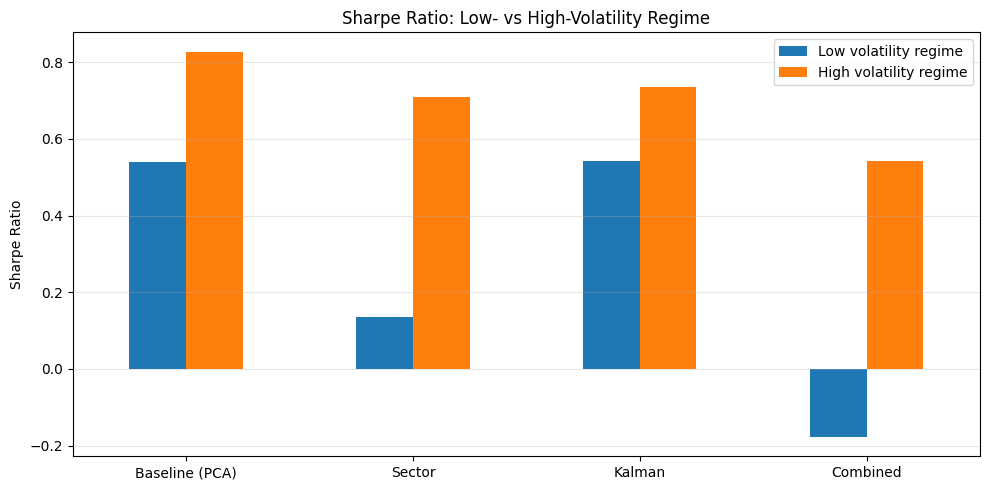

In [14]:
sharpe_by_vol = pd.DataFrame({
    name: tbl["sharpe_ratio"] for name, tbl in analysis["vol_tables"].items()
})
sharpe_by_vol.columns = ["Baseline (PCA)", "Sector", "Kalman", "Combined"]
print("Sharpe ratio, split by trailing benchmark volatility (median split):")
print(sharpe_by_vol.round(2).to_string())

sharpe_by_vol.T.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Sharpe Ratio")
plt.title("Sharpe Ratio: Low- vs High-Volatility Regime")
plt.legend(title=None)
plt.grid(alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The pattern is consistent across all four variants: each performs better in the high-volatility half
of the sample than in the low-volatility half. This is the expected signature of a mean-reversion
strategy, since larger dislocations produce larger s-scores and more trading opportunities. That it
holds regardless of factor model or O-U estimator suggests it is a property of the strategy family
rather than of any single variant.

## 5.3 Walk-forward entry-threshold selection

Section 6.1 of the original notebook sweeps the entry threshold $s_{bo}$ and reports whichever value
gives the best full-sample Sharpe ratio, using information that would not have been available in
real time. The same grid is walked forward here with no look-ahead: for each calendar fold the
threshold is chosen on prior folds only, applied strictly out of sample to the current fold, and the
out-of-sample segments are chained into a single equity curve.

The procedure reuses the s-scores and O-U parameters of the beta-neutral baseline from Section 1,
which is cheap, rather than re-running the full factor-model pipeline for every threshold.

Full-sample stats per entry threshold (beta-neutral):
      total_return  annualized_return  annualized_volatility  sharpe_ratio  max_drawdown
s_bo                                                                                    
0.75         0.300              0.029                  0.038         0.749        -0.075
1.00         0.263              0.025                  0.040         0.629        -0.101
1.25         0.421              0.039                  0.045         0.848        -0.073
1.50         0.570              0.050                  0.052         0.960        -0.060
1.75         0.644              0.055                  0.061         0.896        -0.105
2.00         0.681              0.057                  0.074         0.779        -0.167


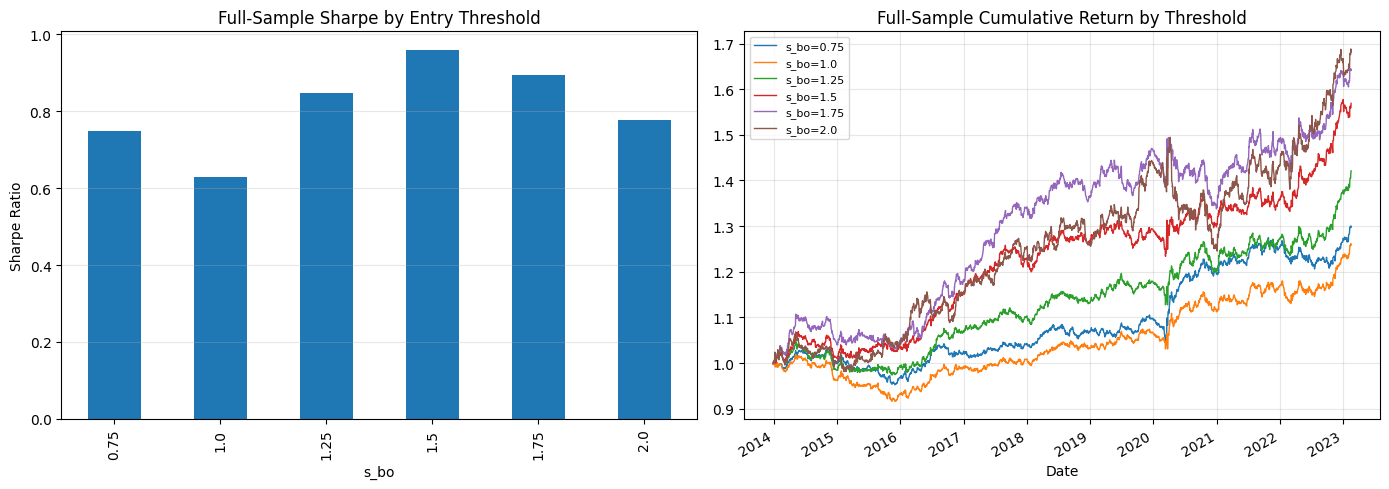

In [15]:
threshold_stats = pd.DataFrame({
    thr: compute_strategy_statistics(cum.dropna())
    for thr, cum in analysis["threshold_results"].items()
}).T
threshold_stats.index.name = "s_bo"
print("Full-sample stats per entry threshold (beta-neutral):")
print(threshold_stats.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
threshold_stats["sharpe_ratio"].plot(kind="bar", ax=axes[0], color="tab:blue")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].set_title("Full-Sample Sharpe by Entry Threshold")
axes[0].grid(alpha=0.3, axis="y")

for thr, cum in analysis["threshold_results"].items():
    cum.plot(ax=axes[1], label=f"s_bo={thr}", linewidth=1)
axes[1].set_title("Full-Sample Cumulative Return by Threshold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Thresholds chosen by the walk-forward procedure, fold by fold (no look-ahead):
2016-01-01 to 2018-01-01    1.75
2018-01-01 to 2019-01-01    1.75
2019-01-01 to 2020-01-01    1.75
2020-01-01 to 2021-01-01    1.75
2021-01-01 to 2022-01-01    1.50
2022-01-01 to 2023-01-01    1.75
2023-01-01 to 2023-12-31    1.50
dtype: float64

                                                       total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
In-sample-optimal (look-ahead, full sample)                 57.03%             4.97%                 5.17%         0.96       -6.00%
Walk-forward OOS, beta-neutral                              47.05%             5.46%                 6.17%         0.88      -10.50%
Walk-forward OOS, WITHOUT beta hedge (for comparison)       13.47%             1.76%                 7.74%         0.23      -27.64%


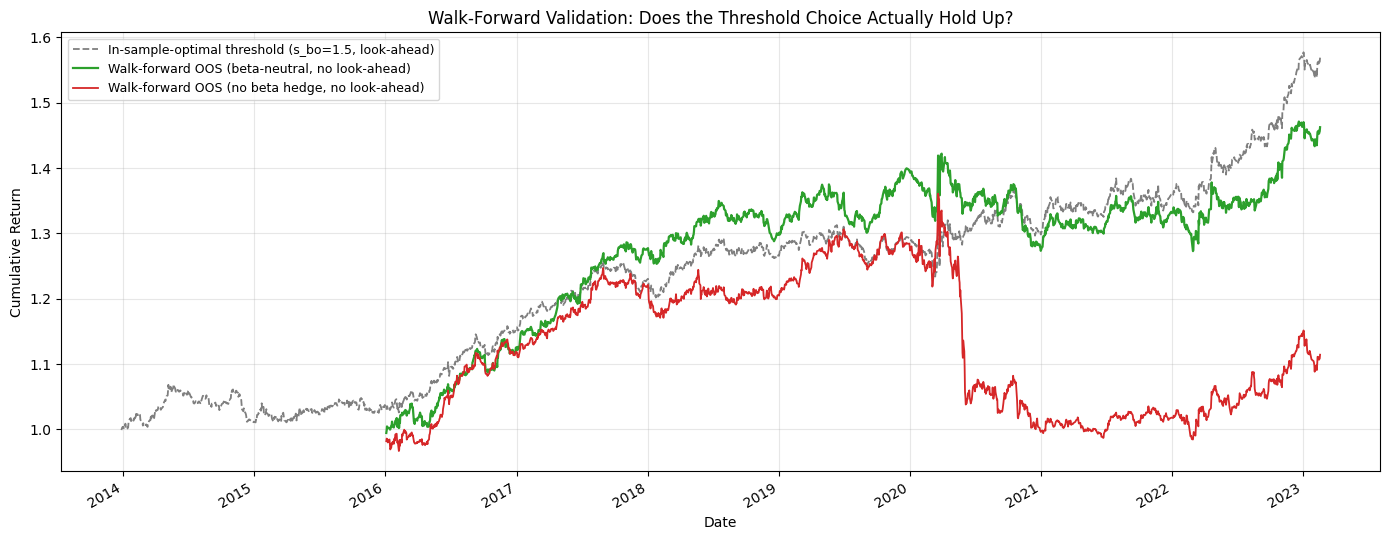

In [16]:
print("Thresholds chosen by the walk-forward procedure, fold by fold (no look-ahead):")
print(analysis["chosen_thresholds"])

comparison_wf_display = format_stats_table({
    "In-sample-optimal (look-ahead, full sample)": analysis["best_stats_full"],
    "Walk-forward OOS, beta-neutral": analysis["oos_stats"],
    "Walk-forward OOS, WITHOUT beta hedge (for comparison)": analysis["oos_stats_plain"],
})
print("\n", comparison_wf_display.to_string())

plt.figure(figsize=(14, 5.5))
analysis["threshold_results"][analysis["best_thr_full"]].plot(
    label=f"In-sample-optimal threshold (s_bo={analysis['best_thr_full']}, look-ahead)",
    linewidth=1.3, linestyle="--", color="tab:gray",
)
analysis["oos_cum"].plot(label="Walk-forward OOS (beta-neutral, no look-ahead)", linewidth=1.6, color="tab:green")
analysis["oos_cum_plain"].plot(label="Walk-forward OOS (no beta hedge, no look-ahead)", linewidth=1.3, color="tab:red")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Walk-Forward Validation: Does the Threshold Choice Actually Hold Up?")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two results stand out.

1. **With the beta hedge, walk-forward selection holds up.** The chained out-of-sample curve reaches
   Sharpe 0.88 against 0.96 for the look-ahead optimum, a real but modest degradation, and the
   thresholds chosen fold by fold (1.75, then 1.50) stay close to the full-sample optimum of 1.50.
2. **Without the hedge, the same procedure is fragile.** Sharpe falls to 0.23 and out-of-sample
   maximum drawdown widens from -10.5% to -27.6%.

The second point connects back to Section 1.2. Hedging out market beta does not only lift the
point-estimate Sharpe ratio, it materially reduces the strategy's sensitivity to a hyperparameter
that has to be chosen without hindsight. A strategy whose live performance depends on picking one
threshold correctly is fragile whatever its backtested Sharpe ratio looks like.

---
# 6. Summary and conclusions

In [17]:
final_summary_display = format_stats_table({
    "Baseline: PCA + OLS (as shipped, alpha bug)": baseline["stats_no_alpha"],
    "Baseline: PCA + OLS (alpha-fixed)": baseline["stats"],
    "Baseline: PCA + OLS (alpha-fixed, beta-neutral)": baseline["stats_bn"],
    "Sector factors + OLS": sector["stats"],
    "PCA + Kalman O-U": kalman["stats"],
    "Combined: Sector + Kalman": combined["stats"],
    "Walk-forward OOS (beta-neutral, no look-ahead)": analysis["oos_stats"],
})
print(final_summary_display.to_string())

                                                total_return annualized_return annualized_volatility sharpe_ratio max_drawdown
Baseline: PCA + OLS (as shipped, alpha bug)           41.57%             3.81%                 5.49%         0.69       -9.54%
Baseline: PCA + OLS (alpha-fixed)                     40.79%             3.74%                 5.48%         0.68       -9.54%
Baseline: PCA + OLS (alpha-fixed, beta-neutral)       42.14%             3.85%                 4.54%         0.85       -7.33%
Sector factors + OLS                                  29.91%             2.85%                 6.37%         0.45      -11.19%
PCA + Kalman O-U                                      38.87%             3.59%                 5.72%         0.63       -9.98%
Combined: Sector + Kalman                             13.94%             1.41%                 6.46%         0.22      -14.81%
Walk-forward OOS (beta-neutral, no look-ahead)        47.05%             5.46%                 6.17%         0.

## What worked

- **Applying the beta-neutral hedge** that the original notebook computed and discarded was the
  single largest improvement: Sharpe 0.68 to 0.85, drawdown -9.5% to -7.3%, and, per Section 5.3, a
  markedly less threshold-sensitive strategy out of sample.
- **Wiring alpha into the modified s-score** aligns the code with the paper's own formula. Its
  measured effect on this universe is within noise (0.69 to 0.68).
- **Walk-forward validation** of the beta-neutral strategy degraded only modestly against the
  look-ahead optimum (0.88 vs. 0.96), which is not the profile of a badly overfit threshold.

## What did not, and why it is still worth reporting

- **Sector factors underperformed PCA** on this 50-stock universe (Sharpe 0.45 vs. 0.85), traceable
  to a lower in-sample R² (62.5% vs. 76.1%, Section 2.1) and ultimately to GICS being a fixed and
  unbalanced taxonomy rather than a variance-maximizing decomposition. Regime by regime, however,
  sector factors were the best performer through the 2020 crash. "Worse on average" and "worse in
  every regime" are different statements, and the distinction is the one that matters for risk
  management.
- **Kalman-filtered O-U estimation** produced more informative within-window parameter paths but a
  lower Sharpe ratio than the static fit (0.63 vs. 0.85). Smoothing away noise also slows the
  reaction to a genuine regime change, and for this signal the second effect dominated.
- **The two extensions combined** compounded their shortfalls instead of cancelling them (Sharpe
  0.22), the weakest configuration tested.

## Takeaway

The best-performing configuration in this notebook is not a new factor model or a more sophisticated
estimator. It is a correctly market-neutral implementation of the original strategy, validated with
thresholds chosen out of sample. The two findings that came from reading the existing code, an
unused hedge and a mis-wired formula, mattered more here than either methodological extension.